## Load Packages and libraries 

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

import os
from scipy.sparse import coo_matrix


## Data loading and preprocess

In [24]:
train_data =pd.read_csv("marketing_sample_for_walmart_com-walmart_com_product_review__20200701_20201231__5k_data.tsv",sep='\t')

train_data.columns


Index(['Uniq Id', 'Crawl Timestamp', 'Dataset Origin', 'Product Id',
       'Product Barcode', 'Product Company Type Source',
       'Product Brand Source', 'Product Brand Normalised Source',
       'Product Name Source', 'Match Rank', 'Match Score', 'Match Type',
       'Retailer', 'Product Category', 'Product Brand', 'Product Name',
       'Product Price', 'Sku', 'Upc', 'Product Url', 'Market',
       'Product Description', 'Product Currency',
       'Product Available Inventory', 'Product Image Url',
       'Product Model Number', 'Product Tags', 'Product Contents',
       'Product Rating', 'Product Reviews Count', 'Bsr', 'Joining Key'],
      dtype='object')

In [26]:
train_data.head(2)

,Uniq Id,Crawl Timestamp,Dataset Origin,Product Id,Product Barcode,Product Company Type Source,Product Brand Source,Product Brand Normalised Source,Product Name Source,Match Rank,...,Product Currency,Product Available Inventory,Product Image Url,Product Model Number,Product Tags,Product Contents,Product Rating,Product Reviews Count,Bsr,Joining Key
0,1705736792d82aa2f2d3caf1c07c53f4,2020-09-24 03:21:12 +0000,NaN,2e17bf4acecdece67fc00f07ad62c910,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",NaN,NaN,NaN,NaN,81350af1be98d3753cf964709f0c766a
1,95a9fe6f4810fcfc7ff244fd06784f11,2020-10-30 14:04:08 +0000,NaN,076e5854a62dd283c253d6bae415af1f,NaN,Competitor,NaN,NaN,NaN,NaN,...,USD,111111111,https://i5.walmartimages.com/asr/9c8e42e4-13a5...,NaN,"Nice 'n Easy Permanent Color, 111 Natural Medi...",NaN,NaN,NaN,NaN,0353e63907dc0de0c734db4690300057


In [30]:
train_data.shape

(5000, 32)

### extracting the important columns

In [39]:
train_data = train_data[['Uniq Id','Product Id', 'Product Rating', 'Product Reviews Count', 'Product Category', 'Product Brand', 'Product Name', 'Product Image Url', 'Product Description', 'Product Tags']]
train_data.head(2)

,Uniq Id,Product Id,Product Rating,Product Reviews Count,Product Category,Product Brand,Product Name,Product Image Url,Product Description,Product Tags
0,1705736792d82aa2f2d3caf1c07c53f4,2e17bf4acecdece67fc00f07ad62c910,NaN,NaN,Premium Beauty > Premium Makeup > Premium Nail...,OPI,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,NaN,"OPI Infinite Shine, Nail Lacquer Nail Polish, ..."
1,95a9fe6f4810fcfc7ff244fd06784f11,076e5854a62dd283c253d6bae415af1f,NaN,NaN,Beauty > Hair Care > Hair Color > Auburn Hair ...,Nice'n Easy,"Nice n Easy Permanent Color, 111 Natural Mediu...",https://i5.walmartimages.com/asr/9c8e42e4-13a5...,Pack of 3 Pack of 3 for the UPC: 381519000201 ...,"Nice 'n Easy Permanent Color, 111 Natural Medi..."


In [43]:
train_data['Product Tags']

0       OPI Infinite Shine, Nail Lacquer Nail Polish, ...
1       Nice 'n Easy Permanent Color, 111 Natural Medi...
2       Clairol Nice 'N Easy Permanent Color 7/106A Na...
3       Kokie Professional Matte Lipstick, Hot Berry, ...
4       Gillette TRAC II Plus Razor Blade Refills, Fit...
                              ...                        
4995    Garden Mint Room Spray (Double Strength), 4 ou...
4996    Garnier Nutrisse Nourishing Hair Color Creme (...
4997    Nail File Electric Drill, 6 in 1 Professional ...
4998    Creed Love In Black Hair And Body Wash 6.8oz/2...
4999                    Foundation, Wal-mart, Walmart.com
Name: Product Tags, Length: 5000, dtype: object

In [45]:
train_data.isnull().sum()

Uniq Id                     0
Product Id                  0
Product Rating           2806
Product Reviews Count    1654
Product Category           10
Product Brand              13
Product Name                0
Product Image Url           0
Product Description      1127
Product Tags                0
dtype: int64

In [309]:
train_data.duplicated().sum()

1

In [53]:
# filling the missing values with 0 and ''

train_data['Product Rating'] = train_data['Product Rating'].fillna(0)
train_data['Product Reviews Count'] = train_data['Product Reviews Count'].fillna(0)
train_data['Product Category'] = train_data['Product Category'].fillna('')
train_data['Product Brand'] = train_data['Product Brand'].fillna('')
train_data['Product Description'] = train_data['Product Description'].fillna('')


In [55]:
train_data.isnull().sum()

Uniq Id                  0
Product Id               0
Product Rating           0
Product Reviews Count    0
Product Category         0
Product Brand            0
Product Name             0
Product Image Url        0
Product Description      0
Product Tags             0
dtype: int64

In [315]:
train_data = train_data.drop_duplicates()
train_data.duplicated().sum()

0

In [321]:
train_data.shape

(4999, 10)

In [323]:
# making the column shorter 

column_name_mapping = {
    'Uniq Id': 'ID',
    'Product Id': 'ProdID',
    'Product Rating': 'Rating',
    'Product Reviews Count': 'ReviewCount',
    'Product Category': 'Category',
    'Product Brand': 'Brand',
    'Product Name': 'Name',
    'Product Image Url': 'ImageURL',
    'Product Description': 'Description',
    'Product Tags': 'Tags',
    'Product Contents': 'Contents'
}
# rename the columns according to mapping
train_data.rename(columns=column_name_mapping,inplace =True)

In [325]:
train_data.head(1)

,Id,ProdId,Rating,ReviewCount,Category,Brand,Name,ImageURL,Description,Tags
0,1.705737e+09,2.0,0.0,0.0,"premium, beauty, premium, makeup, premium, nai...",opi,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"premium, beauty, premium, makeup, premium, nai..."


In [327]:

train_data['Id'] = train_data['Id'].astype(str)
train_data['ProdId'] = train_data['ProdId'].astype(str)


In [329]:
train_data['Id'] = train_data['Id'].str.extract(r'(\d+)').astype(float)
train_data['ProdId'] = train_data['ProdId'].str.extract(r'(\d+)').astype(float)

In [331]:
train_data.head(1)

,Id,ProdId,Rating,ReviewCount,Category,Brand,Name,ImageURL,Description,Tags
0,1.705737e+09,2.0,0.0,0.0,"premium, beauty, premium, makeup, premium, nai...",opi,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"premium, beauty, premium, makeup, premium, nai..."


## EDA

In [334]:
# Number of Unique users
users=train_data['Id'].nunique()
items=train_data['ProdId'].nunique()
ratings=train_data['Rating'].nunique()

print(f"number of unique users :",users)
print(f"number of unique items :",items)
print(f"number of unique ratings :",ratings)

number of unique users : 1718
number of unique items : 1669
number of unique ratings : 36


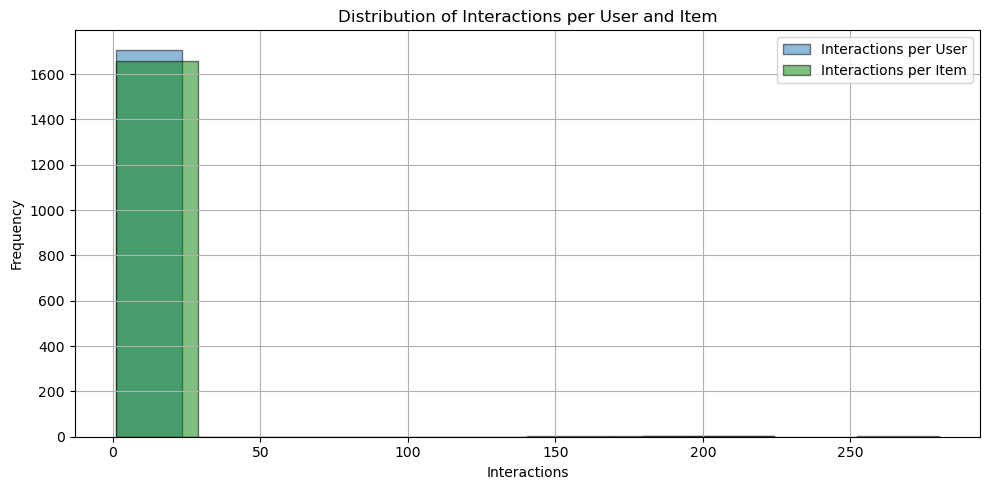

In [336]:
# distribution of interaction
# Plot distribution of interactions per user and item on the same graph
plt.figure(figsize=(10,5))
# Plot interactions per user ('ID')
train_data['Id'].value_counts().hist(bins=10, edgecolor='k', alpha=0.5, label='Interactions per User')

# Plot interactions per item ('ProdID')
train_data['ProdId'].value_counts().hist(bins=10, edgecolor='k', color='green', alpha=0.5, label='Interactions per Item')

# Adding labels and title
plt.xlabel('Interactions')
plt.ylabel('Frequency')
plt.title('Distribution of Interactions per User and Item')

# Add legend to distinguish the two distributions
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


here, Most of the interactions are kindly zero


Text(0.5, 1.0, 'Most Popular items')

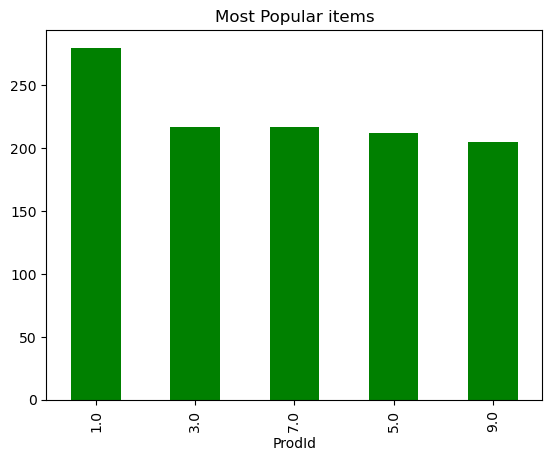

In [339]:
# Most popular items
popular_items = train_data['ProdId'].value_counts().head(5)
popular_items.plot(kind='bar',color='green')
plt.title("Most Popular items")

Text(0.5, 1.0, 'Most popular rating')

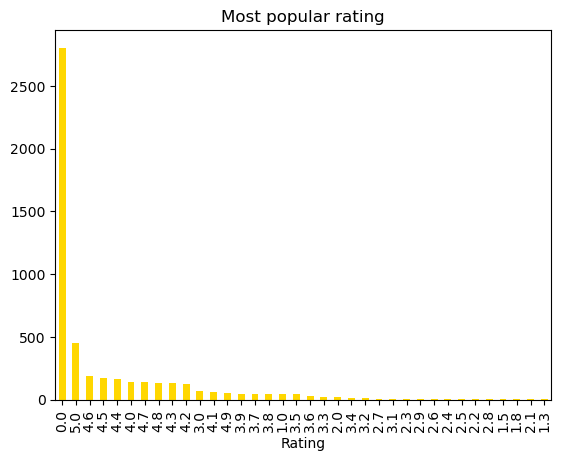

In [341]:
# most rated counts
train_data['Rating'].value_counts().plot(kind='bar',color='gold')
plt.title('Most popular rating')

## Tags Creation

In [344]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

# load the spaCy model for english
nlp = spacy.load("en_core_web_sm")

# function to clean and extract text from text

def clean_and_extract_tags(text):
    doc= nlp(text.lower())

    tags=[token.text for token in doc if token.text.isalnum() and token.text not in STOP_WORDS]    

    return ', '.join(tags)


columns_to_extract_tags_from = ['Category', 'Brand', 'Description']

for columns in columns_to_extract_tags_from:
    train_data[columns]=train_data[columns].apply(clean_and_extract_tags)


Extract Tags:

token.text.isalnum(): Filters out non-alphanumeric tokens, such as punctuation, special characters, or numbers that don't convey useful meaning (e.g., "!", "$").

token.text not in STOP_WORDS: Filters out stopwords (common words like "and", "the", "is") from the text. Only the words that have useful meaning for tagging are kept.

This creates a list of tokens (words) that are alphanumeric and not stopwords. These filtered words are used as tags.

Return Processed Tags:
', '.join(tags): Joins the list of tags into a single string, with each tag separated by a comma and a space (e.g., "great, product").

In [386]:
# concatenate the cleaned tags from all relevant columns:
train_data['Tags']= train_data[columns_to_extract_tags_from].apply(lambda row: ', '.join(row) ,axis=1)

The lambda function lambda row: ', '.join(row) is applied to each row of the selected columns (Category, Brand, Description, etc.). For each row:
row is a Series representing the values of the row across the relevant columns.

', '.join(row): Joins the values of the row into a single string, with each value separated by a comma and a space.

This results in a string of concatenated tags for each row (e.g., "electronics, Samsung, great, product, high, quality").

In [482]:
train_data.head(1)

,Id,ProdId,Rating,ReviewCount,Category,Brand,Name,ImageURL,Description,Tags
0,1.705737e+09,2.0,0.0,0.0,"premium, beauty, premium, makeup, premium, nai...",opi,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"premium, beauty, premium, makeup, premium, nai..."


## Rating Base Recommendation


When a new user visits a website for the first time and there is no historical data about their preferences (a common "cold start" problem in recommendation systems), the website can handle this by providing a default recommendation list. One effective strategy is to display a list of products with the highest overall ratings or most popular items


In [393]:
 rate =train_data.groupby(['Name','ReviewCount','Brand','ImageURL'])['Rating'].mean().reset_index()


In [395]:
print(type(rate))

<class 'pandas.core.frame.DataFrame'>


In [397]:
top_rated_items = rate.sort_values(by='Rating',ascending =False)
rating_base_recommendation= top_rated_items.head(10)

In [399]:
rating_base_recommendation.loc[:, 'Rating'] = rating_base_recommendation['Rating'].astype(int)
rating_base_recommendation.loc[:, 'ReviewCount'] = rating_base_recommendation['ReviewCount'].astype(int)


In [401]:
rating_base_recommendation

,Name,ReviewCount,Brand,ImageURL,Rating
1686,"Electric Shaver, Triple Shaving Time Electric ...",4.0,moosoo,https://i5.walmartimages.com/asr/e7dcd553-90df...,5.0
526,"Alaffia Body Lotion, Vanilla, 32 Oz",2.0,alaffia,https://i5.walmartimages.com/asr/2988c323-cb6f...,5.0
2053,"Gold Bond Ultimate Ultimate Healing Lotion, Al...",2.0,"gold, bond",https://i5.walmartimages.com/asr/34b610e7-05db...,5.0
4716,"Versace Man Eau Fraiche Eau De Toilette Spray,...",24.0,versace,https://i5.walmartimages.com/asr/edaaeed5-9da0...,5.0
2058,Goldwell StyleSign 1 Flat Marvel Straightening...,2.0,goldwell,https://i5.walmartimages.com/asr/3bf90289-6980...,5.0
3842,"Red Devil 0322 Steel Wool # 00 Very Fine, 8 Pa...",1.0,"red, devil",https://i5.walmartimages.com/asr/60bfe5ba-774c...,5.0
510,"Air Wick Plug in Starter Kit, Warmer + 1 Refil...",1.0,"air, wick",https://i5.walmartimages.com/asr/0fac65b2-c6aa...,5.0
3841,Recovery Complex Anti-Frizz Shine Serum by Bai...,4.0,"bain, de, terre",https://i5.walmartimages.com/asr/fcdb4d2e-3727...,5.0
2687,Long Aid Extra Dry Formula Curl Activator Gel ...,12.0,"long, aid",https://i5.walmartimages.com/asr/f7f29199-bfa5...,5.0
2062,"Good Sense 60-Day Air Care System, Citrus, 2 o...",1.0,diversey,https://i5.walmartimages.com/asr/025a7068-7bb1...,5.0


In [639]:
df= pd.DataFrame(rating_base_recommendation)

# Save the DataFrame to a CSV file
output_file = "Downloads/my_data.csv"
df.to_csv(output_file, index=False)


## Content Based Recommendation System 
### (User Preferences or Items similarities )

Content-based recommendation is a type of recommendation system that suggests items to users based on the characteristics of the items and the preferences that the user has shown in the past. This approach makes recommendations by comparing the content (features) of items that a user has liked or interacted with to other items in the catalog.

In [405]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [407]:
train_data.head(1)

,Id,ProdId,Rating,ReviewCount,Category,Brand,Name,ImageURL,Description,Tags
0,1.705737e+09,2.0,0.0,0.0,"premium, beauty, premium, makeup, premium, nai...",opi,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"premium, beauty, premium, makeup, premium, nai..."


In [409]:
tfidf_vectorizer=TfidfVectorizer(stop_words='english')

tfidf_matrix_content = tfidf_vectorizer.fit_transform(train_data['Tags'])

cosine_similarities_content = cosine_similarity(tfidf_matrix_content,tfidf_matrix_content)


In [410]:
cosine_similarities_content

array([[1.        , 0.00347533, 0.0036318 , ..., 0.13535613, 0.31724891,
        0.05688889],
       [0.00347533, 1.        , 0.38085052, ..., 0.02315268, 0.00183881,
        0.0381036 ],
       [0.0036318 , 0.38085052, 1.        , ..., 0.03959976, 0.00192161,
        0.05910722],
       ...,
       [0.13535613, 0.02315268, 0.03959976, ..., 1.        , 0.00122986,
        0.03792814],
       [0.31724891, 0.00183881, 0.00192161, ..., 0.00122986, 1.        ,
        0.00544337],
       [0.05688889, 0.0381036 , 0.05910722, ..., 0.03792814, 0.00544337,
        1.        ]])

### Similarity of name present in name column

In [437]:
item_name = 'OPI Infinite Shine, Nail Lacquer Nail Polish, Bubble Bath'
item_index = train_data[train_data['Name']==item_name].index[0]

In [415]:
cosine_similarities_content[item_index]

array([1.        , 0.00347533, 0.0036318 , ..., 0.13535613, 0.31724891,
       0.05688889])

In [417]:
list(enumerate(cosine_similarities_content[item_index]))

[(0, 1.0),
 (1, 0.0034753250015039255),
 (2, 0.0036318007467874944),
 (3, 0.01315049695875191),
 (4, 0.0010158748086556229),
 (5, 0.006574886092424324),
 (6, 0.007327450922173563),
 (7, 0.051510640980318864),
 (8, 0.011108383636316997),
 (9, 0.003151293712383452),
 (10, 0.0),
 (11, 0.15874357583092003),
 (12, 0.040969723425808444),
 (13, 0.0030464758206487407),
 (14, 0.0),
 (15, 0.005968592303497538),
 (16, 0.33986507338317423),
 (17, 0.0),
 (18, 0.004555501609637089),
 (19, 0.003888215955239068),
 (20, 0.008762876907482476),
 (21, 0.0),
 (22, 0.009457562939358429),
 (23, 0.0),
 (24, 0.005174864508452745),
 (25, 0.0),
 (26, 0.007171941445339257),
 (27, 0.0032593449442956564),
 (28, 0.28119022576309805),
 (29, 0.0),
 (30, 0.007206154847111737),
 (31, 0.006228711383490424),
 (32, 0.00877200766621728),
 (33, 0.01076338939085507),
 (34, 0.0056377214853930765),
 (35, 0.010258790038632221),
 (36, 0.0020161223057559856),
 (37, 0.0032777327964091476),
 (38, 0.005163290631233591),
 (39, 0.0),
 

In [439]:
similar_items = list(enumerate(cosine_similarities_content[item_index]))


In [506]:
similar_items = sorted(similar_items, key=lambda x:x[1], reverse=True)
top_similar_items = similar_items[1:10]

In [510]:
recommended_items_indics = [x[0] for x in top_similar_items]

In [512]:
train_data.iloc[recommended_items_indics][['Name','ReviewCount','Brand']]

,Name,ReviewCount,Brand
156,OPI Nail Lacquer Polish .5oz/15mL - This Gown ...,0.0,opi
184,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,0.0,opi
205,OPI Nail Lacquer - Dont Bossa Nova Me Around -...,0.0,opi
237,OPI Infinite Shine 2 Polish - ISL P33 - Alpaca...,5.0,opi
325,OPI Gel Polish Fall 2019 Scotland Collection G...,1.0,opi
375,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi
402,"OPI Nail Polish, Strawberry Margarita, 0.5 Fl Oz",57.0,opi
706,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi
886,OPI- Nail Lacquer-GelColor - &quotLiv&quotin t...,0.0,opi


### Similarity of User provided input 

In [516]:
# User-provided input
item_name = input("enter the name")

# Ensure no NaN or empty strings in the 'Name' column
train_data['Tags'] = train_data['Tags'].fillna('')

# Combining user input with the dataset
combined_names = train_data['Tags'].tolist() + [item_name]

# Creating the TF-IDF matrix
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix_content = tfidf_vectorizer.fit_transform(combined_names)

# Computing cosine similarity between the input and dataset items
cosine_similarities_content = cosine_similarity(tfidf_matrix_content[-1], tfidf_matrix_content[:-1])  # Last row is user input

# Get similarity scores for each item
similarity_scores = list(enumerate(cosine_similarities_content[0]))

# Sort items by similarity scores
similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)


# Get the indices of the top N most similar items
top_similar_items = similarity_scores[:10]

# Extract the recommended items' indices
recommended_items_indices = [x[0] for x in top_similar_items]

# Display the recommended items
train_data.iloc[recommended_items_indices][['Name', 'ReviewCount', 'Brand']]



enter the name nail polish


,Name,ReviewCount,Brand
1865,Sally Hansen Miracle Gel Nail Color Polish Sma...,11132.0,"sally, hansen"
4498,Sally Hansen Miracle Gel Nail Color Polish In ...,10841.0,"sally, hansen"
0,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",0.0,opi
156,OPI Nail Lacquer Polish .5oz/15mL - This Gown ...,0.0,opi
184,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,0.0,opi
205,OPI Nail Lacquer - Dont Bossa Nova Me Around -...,0.0,opi
237,OPI Infinite Shine 2 Polish - ISL P33 - Alpaca...,5.0,opi
325,OPI Gel Polish Fall 2019 Scotland Collection G...,1.0,opi
375,OPI Nail Gel Polish GelColor .5oz/15mL 3 CT Co...,1.0,opi
402,"OPI Nail Polish, Strawberry Margarita, 0.5 Fl Oz",57.0,opi


### Function To Recommend Products for Content Base **

In [535]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

def  content_based_recommendations(train_data, input_name, top_n=10):
    # Ensure the 'Tags' column has no NaN values
    train_data['Tags'] = train_data['Tags'].fillna('')

    # Combine the input name with the dataset's 'Tags'
    combined_tags = train_data['Tags'].tolist() + [input_name]

    # Create a TF-IDF vectorizer for the tags
    tfidf_vectorizer = TfidfVectorizer(stop_words='english')

    # Apply TF-IDF vectorization to tags and the input name
    tfidf_matrix_content = tfidf_vectorizer.fit_transform(combined_tags)

    # Calculate cosine similarity between the input and dataset items
    cosine_similarities_content = cosine_similarity(tfidf_matrix_content[-1], tfidf_matrix_content[:-1])  # Last row is the input

    # Get similarity scores for each item in the dataset
    similarity_scores = list(enumerate(cosine_similarities_content[0]))

    # Sort similar items by similarity score in descending order
    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    # Get the top N most similar items
    top_similar_items = similarity_scores[:top_n]

    # Get the indices of the top similar items
    recommended_item_indices = [x[0] for x in top_similar_items]

    # Get the details of the top similar items
    recommended_items_details = train_data.iloc[recommended_item_indices][['Name', 'ReviewCount', 'Brand','ImageURL', 'Tags']]

    return recommended_items_details



In [537]:
# Example: Get content-based recommendations for a specific item
item_name = 'chair'
content_based_rec = content_based_recommendations(train_data, item_name, top_n=10)

content_based_rec

,Name,ReviewCount,Brand,ImageURL,Tags
4463,Fiberlinks Textiles Inc Waterproof Chair Pad 2...,0.0,"fiberlinks, textiles",https://i5.walmartimages.com/asr/9cad6c7a-bd9a...,"personal, care, incontinence, incontinence, pa..."
975,Stretch Dining Chair Cover Stool Slipcovers Ch...,10.0,piccocasa,https://i5.walmartimages.com/asr/e9284be1-d833...,"home, decor, slipcovers, dining, chair, covers..."
1692,PiccoCasa Spandex Stretch Removable Washable S...,10.0,piccocasa,https://i5.walmartimages.com/asr/fb5c5e40-6f4a...,"home, decor, slipcovers, dining, chair, covers..."
1775,Stretch Dining Chair Cover Stool Slipcovers Ch...,11.0,piccocasa,https://i5.walmartimages.com/asr/e8bc4f45-299f...,"home, decor, slipcovers, dining, chair, covers..."
2209,Piccocasa 1-Piece Wear Resistant Polyester Spa...,10.0,piccocasa,https://i5.walmartimages.com/asr/43e73a2c-afba...,"home, decor, slipcovers, dining, chair, covers..."
3500,Blue Jay Absorb n Protect Incontinent Chair Pa...,0.0,"blue, jay, elite, healthcare, brand",https://i5.walmartimages.com/asr/faff3ef9-0915...,"personal, care, incontinence, incontinence, bl..."
3216,"Healthline Reusable Underpads, Washable Reusab...",3.0,healthline,https://i5.walmartimages.com/asr/e39232c1-385f...,"personal, care, incontinence, incontinence, he..."
1028,"Urinary Drainage Bag Holder, 11&quot x 11.5&qu...",3.0,mckesson,https://i5.walmartimages.com/asr/eb8b17c7-9889...,"personal, care, incontinence, incontinence, mc..."
4983,Covidien Simplicity Underpad - 7136CS - 23&quo...,0.0,covidien,https://i5.walmartimages.com/asr/2b5ce91e-7b16...,"personal, care, incontinence, incontinence, co..."
391,Elf Star Cotton Bamboo Fiber Breathable Waterp...,0.0,"elf, star",https://i5.walmartimages.com/asr/50da12da-4a50...,"personal, care, incontinence, incontinence, el..."


## Collaborative Filtering (User Item Similarity)

Collaborative filtering is a recommender system that uses user-generated content to suggest items to users based on the preferences of similar users

In [561]:
train_data.head(2)

,Id,ProdId,Rating,ReviewCount,Category,Brand,Name,ImageURL,Description,Tags
0,1.705737e+09,2.0,0.0,0.0,"premium, beauty, premium, makeup, premium, nai...",opi,"OPI Infinite Shine, Nail Lacquer Nail Polish, ...",https://i5.walmartimages.com/asr/0e1f4c51-c1a4...,,"premium, beauty, premium, makeup, premium, nai..."
1,9.500000e+01,76.0,0.0,0.0,"beauty, hair, care, hair, color, auburn, hair,...",easy,"Nice n Easy Permanent Color, 111 Natural Mediu...",https://i5.walmartimages.com/asr/9c8e42e4-13a5...,"pack, 3, pack, 3, upc, 381519000201, beautiful...","beauty, hair, care, hair, color, auburn, hair,..."


In [567]:
train_data.pivot_table(index='Id', columns='ProdId', values='Rating',aggfunc='mean').fillna(0)

ProdId,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00,7.000000e+00,8.000000e+00,9.000000e+00,...,2.078212e+13,6.207058e+13,9.309646e+13,1.001019e+14,6.813873e+14,7.323091e+14,7.885477e+14,2.693233e+15,6.958062e+15,9.372896e+15
Id,,,,,,,,,,,,,,,,,,,,,
0.000000e+00,2.840000,1.711111,2.057143,1.587500,1.775000,0.000000,2.433333,1.580000,1.000000,1.011111,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1.000000e+00,1.720000,2.383333,2.122222,2.753846,0.700000,2.333333,3.325000,2.340000,0.000000,2.422222,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2.000000e+00,1.285714,1.700000,3.062500,2.150000,2.663636,1.690909,1.371429,2.237500,1.336364,1.900000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3.000000e+00,1.740000,2.700000,1.583333,2.675000,0.785714,3.314286,1.290000,0.000000,1.150000,3.540000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4.000000e+00,3.525000,1.071429,2.462500,1.960000,1.550000,1.942857,0.415385,2.555556,2.130000,3.183333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4.799034e+12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.700000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8.186981e+12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8.684094e+12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [569]:
user_item_matrix=train_data.pivot_table(index='Id', columns='ProdId', values='Rating',aggfunc='mean').fillna(0)

In [571]:
user_similarity = cosine_similarity(user_item_matrix)

In [573]:
target_user_id = 4
user_item_matrix.index.get_loc(target_user_id)

4

In [577]:
target_user_index = user_item_matrix.index.get_loc(target_user_id)
user_similarities = user_similarity[target_user_index]

In [583]:
similar_user_indices = user_similarities.argsort()[::-1][1:]

In [587]:
recommend_items = []

for user_index in similar_user_indices:
    rated_by_similar_user = user_item_matrix.iloc[user_index]
    not_rated_by_target_user = (rated_by_similar_user==0) & (user_item_matrix.iloc[target_user_index]==0)
    
    recommend_items.extend(user_item_matrix.columns[not_rated_by_target_user][:10])

recommended_items_details = train_data[train_data['ProdId'].isin(recommend_items)][['Name','ReviewCount','Brand','ImageURL','Rating']]

In [589]:
recommended_items_details.head(10)

,Name,ReviewCount,Brand,ImageURL,Rating
61,"COVERGIRL Exhibitionist Cream Lipstick, 395 Da...",713.0,covergirl,https://i5.walmartimages.com/asr/95076ec0-ffbd...,4.3
85,"BioAstin Hawaiian Astaxanthin, Vegan, 12mg, 75 Ct",3.0,bioastin,https://i5.walmartimages.com/asr/6da9e238-b19e...,5.0
86,LOreal Paris Feria Multi-Faceted Shimmering Pe...,2144.0,paris,https://i5.walmartimages.com/asr/c229026a-2b75...,3.1
108,OPI Nail Dipping Powder Perfection Combo - Liq...,1.0,opi,https://i5.walmartimages.com/asr/ef1607ee-5bdb...,3.0
144,Covidien Curity Maternity Pad Heavy 4.33&quot ...,0.0,covidien,https://i5.walmartimages.com/asr/e4e38217-ed43...,0.0
155,"Crest 3D White Brilliance Mouthwash, Alcohol F...",63.0,crest,https://i5.walmartimages.com/asr/1fcc5525-9ae3...,0.0
174,COVERGIRL Outlast All-Day Moisturizing Lip Col...,36.0,covergirl,https://i5.walmartimages.com/asr/4479896f-c6c4...,0.0
193,"Revlon ColorStay Skinny Liquid Liner, 304 Gree...",70.0,revlon,https://i5.walmartimages.com/asr/aa3b20a6-3d6d...,4.5
212,"Comvita Certified UMF 20+ Manuka Honey, Raw & ...",0.0,comvita,https://i5.walmartimages.com/asr/3cdc1498-a2ac...,0.0
241,"Ahava Mens Mineral Hand Cream, 3.4 Oz",0.0,ahava,https://i5.walmartimages.com/asr/f74e4bb7-47d3...,0.0


User-Item Matrix:
Rows are users (ID), columns are products (ProdID), and values are ratings (Rating).
Missing ratings are filled with 0.

User Similarity:
Use cosine_similarity to calculate similarity between users based on their ratings.

Find Similar Users:
Exclude the target user and sort other users by similarity score in descending order.
    
Recommend Items:
For each similar user:
Identify products they have rated.
Exclude products already rated by the target user.
Add these products to the recommendation list.
    
Retrieve Product Details:
Use the ProdID of recommended items to retrieve additional details (e.g., Name, Brand, ReviewCount) from the original dataset.

### Enhanced Collaborative Filtering Code

Normalized Ratings: Normalize user ratings to reduce bias from users who give consistently high or low ratings.
    
Weighted Recommendations: Weight recommendations based on user similarity scores.
    
Efficient Processing: Use a more streamlined approach to avoid redundant computation

In [602]:
def collaborative_filtering_recommendations(train_data, target_user_id, top_n=10):
    
    # Create a User-Item Matrix
    user_item_matrix = train_data.pivot_table(index='Id', columns='ProdId', values='Rating', aggfunc='mean')

    # Normalize Ratings (centered around users' mean)
    user_mean_ratings = user_item_matrix.mean(axis=1)  # Average rating per user
    normalized_matrix = user_item_matrix.sub(user_mean_ratings, axis=0).fillna(0)  # Centered ratings

    # Calculate User Similarities
    user_similarity = cosine_similarity(normalized_matrix)
    target_user_index = user_item_matrix.index.get_loc(target_user_id)
    user_similarities = user_similarity[target_user_index]

    # Sort Similar Users by Similarity Score
    similar_user_indices = np.argsort(user_similarities)[::-1][1:]  # Exclude target user

    ## Weighted Recommendation Scores
    scores = {}
    for user_index in similar_user_indices:
        similar_user_id = user_item_matrix.index[user_index]
        similarity_score = user_similarities[user_index]

        # Retrieve items rated by the similar user
        rated_by_similar_user = user_item_matrix.loc[similar_user_id]
        for item, rating in rated_by_similar_user.dropna().items():
            # Only recommend items not rated by the target user
            if pd.isnull(user_item_matrix.loc[target_user_id, item]):
                # Weighted score: similarity * rating
                if item not in scores:
                    scores[item] = 0
                scores[item] += similarity_score * (rating - user_mean_ratings[similar_user_id])  # Weighted, normalized

    # Rank Recommended Items
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recommended_items = [item for item, score in sorted_scores[:top_n]]

    # Get the details of recommended items
    recommended_items_details = train_data[train_data['ProdId'].isin(recommended_items)][['Name', 'ReviewCount', 'Brand', 'ImageURL', 'Rating']]

    # Return only top 10 recommendations
    return recommended_items_details.head(10)



In [616]:
# Example usage
target_user_id = 100
collaborative_filtering_rec = collaborative_filtering_recommendations(train_data, target_user_id)
collaborative_filtering_rec

,Name,ReviewCount,Brand,ImageURL,Rating
3,"Kokie Professional Matte Lipstick, Hot Berry, ...",0.0,"kokie, cosmetics",https://i5.walmartimages.com/asr/25b4b467-bc61...,0.0
4,"Gillette TRAC II Plus Razor Blade Refills, Fit...",131.0,gillette,https://i5.walmartimages.com/asr/1a2ebb06-cd01...,0.0
8,Suave Extra Hold 7 Shaping Mousse 9 oz (Pack o...,1.0,suave,https://i5.walmartimages.com/asr/05f5ba16-335d...,5.0
9,(3 pack) Vaseline Lip Therapy Tinted Lip Balm ...,950.0,vaseline,https://i5.walmartimages.com/asr/6fced36e-5459...,0.0
15,Clairol Natural Instincts Demi-Permanent Hair ...,2935.0,clairol,https://i5.walmartimages.com/asr/00a6e54a-e431...,3.7
16,Daily Concepts Daily Body Scrubber,10.0,"daily, concepts",https://i5.walmartimages.com/asr/d3e7679d-781e...,4.4
24,Hempz Milk & Honey Herbal Body Moisturizer 2.2...,7.0,hempz,https://i5.walmartimages.com/asr/83e236e5-392c...,0.0
30,2 Pack - AVEENO Active Naturals Intense Relief...,50.0,aveeno,https://i5.walmartimages.com/asr/e87baba7-ece0...,0.0
44,(4 pack) Crest Pro-Health Sensitive & Enamel S...,86.0,crest,https://i5.walmartimages.com/asr/cdf23cc1-475a...,0.0
52,100% Pure Aloe Vera Gel (5-Pack) - Organic Max...,19.0,"simple, wonders",https://i5.walmartimages.com/asr/a2c5c82e-6f82...,4.7


## Hybrid Recommendation System

A hybrid recommendation system combines two or more recommendation techniques to leverage their respective strengths and mitigate their weaknesses. By integrating different recommendation strategies, hybrid systems can provide more accurate, robust, and personalized recommendations.

In [625]:
# Hybrid Recommendation (Combining Content-Based and Collaborative Filtering)
def hybrid_recommendations(train_data,target_user_id, item_name, top_n=10):
    # content-based recommendations
    content_based_rec = content_based_recommendations(train_data,item_name, top_n)

    # collaborative filtering recommendations
    collaborative_filtering_rec = collaborative_filtering_recommendations(train_data,target_user_id, top_n)
    
    # Merge and duplicate the recommendations
    hybrid_rec = pd.concat([content_based_rec, collaborative_filtering_rec]).drop_duplicates()
    
    return hybrid_rec.head(10)

In [629]:
# Example of hybrid recommendations for a specific user and item
target_user_id = 10 # we can change it 
item_name = "Nail Lacquer Polish"  # Change this to the item name
hybrid_rec = hybrid_recommendations(train_data,target_user_id, item_name, top_n=10)

print(f"Top 10 Hybrid Recommendations for User {target_user_id} and Item '{item_name}':")
hybrid_rec

Top 10 Hybrid Recommendations for User 10 and Item 'Nail Lacquer Polish':


,Name,ReviewCount,Brand,ImageURL,Tags,Rating
2631,"Milani Milani Nail Lacquer, 0.45 oz",0.0,milani,https://i5.walmartimages.com/asr/832f0e3f-087b...,"beauty, nail, care, nail, polish, nail, lacque...",NaN
469,"China Glaze Nail Lacquer with Hardeners, Lemon...",1.0,"china, glaze",https://i5.walmartimages.com/asr/10d4a3f7-3730...,"beauty, nail, care, nail, polish, nail, lacque...",NaN
2026,"China Glaze Nail Lacquer with Hardeners, Peach...",0.0,"china, glaze",https://i5.walmartimages.com/asr/30bc31f3-1e89...,"beauty, nail, care, nail, polish, nail, lacque...",NaN
1865,Sally Hansen Miracle Gel Nail Color Polish Sma...,11132.0,"sally, hansen",https://i5.walmartimages.com/asr/dcac19a4-d67e...,"beauty, nail, care, nail, polish, nail, polish...",NaN
3717,"Milani Nail Lacquer, Deep Thoughts",1.0,milani,https://i5.walmartimages.com/asr/b7ab2833-b7e2...,"beauty, nail, care, nail, polish, nail, lacque...",NaN
4498,Sally Hansen Miracle Gel Nail Color Polish In ...,10841.0,"sally, hansen",https://i5.walmartimages.com/asr/5fb5327b-26a1...,"beauty, nail, care, nail, polish, nail, polish...",NaN
971,CHINA GLAZE nail lacquer .5 fl oz.- GOTHIC LOLITA,0.0,"china, glaze",https://i5.walmartimages.com/asr/609b8f36-1f64...,"beauty, nail, care, nail, polish, nail, lacque...",NaN
4430,CHINA GLAZE nail lacquer .5 fl oz.- HAUNTING,0.0,"china, glaze",https://i5.walmartimages.com/asr/cd3a67f6-da81...,"beauty, nail, care, nail, polish, nail, lacque...",NaN
314,Turquoise Waters Hand Soap by Bath and Body Wo...,0.0,"bath, body, works",https://i5.walmartimages.com/asr/8d7a5c9b-90d2...,"personal, care, bath, body, hand, soaps, bath,...",NaN
4645,OPI Nail Lacquer Polish .5oz/15mL - Champagne ...,0.0,opi,https://i5.walmartimages.com/asr/5f4ec827-6edc...,"beauty, nail, care, nail, polish, opi, nail, p...",NaN
